<a href="https://colab.research.google.com/github/Kaitokidbua/ASEAN_Transport/blob/main/ASEAN_Part9_Environment_Fig_33-38.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif' # รองรับภาษาอังกฤษและอ่านง่าย

# --- 1. คลีนและเตรียมข้อมูล ---
df = pd.read_csv("ASEAN_Urban_Growth_Final_with_Mode.csv")

# แปลงวันที่
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# คลีนข้อมูล: ตัดช่วงที่ Ridership เป็น 0 ออก (ถือว่ายังไม่เปิดบริการ)
# เพื่อไม่ให้ตัวหาร (จำนวนวัน) เยอะเกินความจริงจนค่าเฉลี่ยต่ำ
df_active = df[df['Ridership'] > 0].copy()

# คำนวณ Per Capita รายวัน (เพื่อให้สัมพันธ์กับ Population ของปีนั้นๆ)
df_active['Daily_Per_Capita'] = df_active['Ridership'] / (df_active['Population_Million'] * 1_000_000)

# สรุปข้อมูลรายเมือง (ใช้วิธีหาค่าเฉลี่ยรายวันเพื่อแก้ปัญหาจำนวนปีที่มาไม่เท่ากัน)
city_analysis = df_active.groupby(['City', 'Country']).agg({
    'Population_Million': 'last',          # ใช้จำนวนประชากรล่าสุดที่มีใน Dataset
    'Ridership': 'mean',                  # จำนวนผู้โดยสารเฉลี่ยต่อวัน (Daily Avg Volume)
    'Daily_Per_Capita': 'mean'            # utilization เฉลี่ยต่อวัน (Daily Utilization)
}).reset_index()

# เปลี่ยนชื่อ Column ให้สื่อความหมายชัดเจน
city_analysis.columns = ['City', 'Country', 'Latest_Pop_M', 'Avg_Daily_Ridership', 'Utilization_Index']

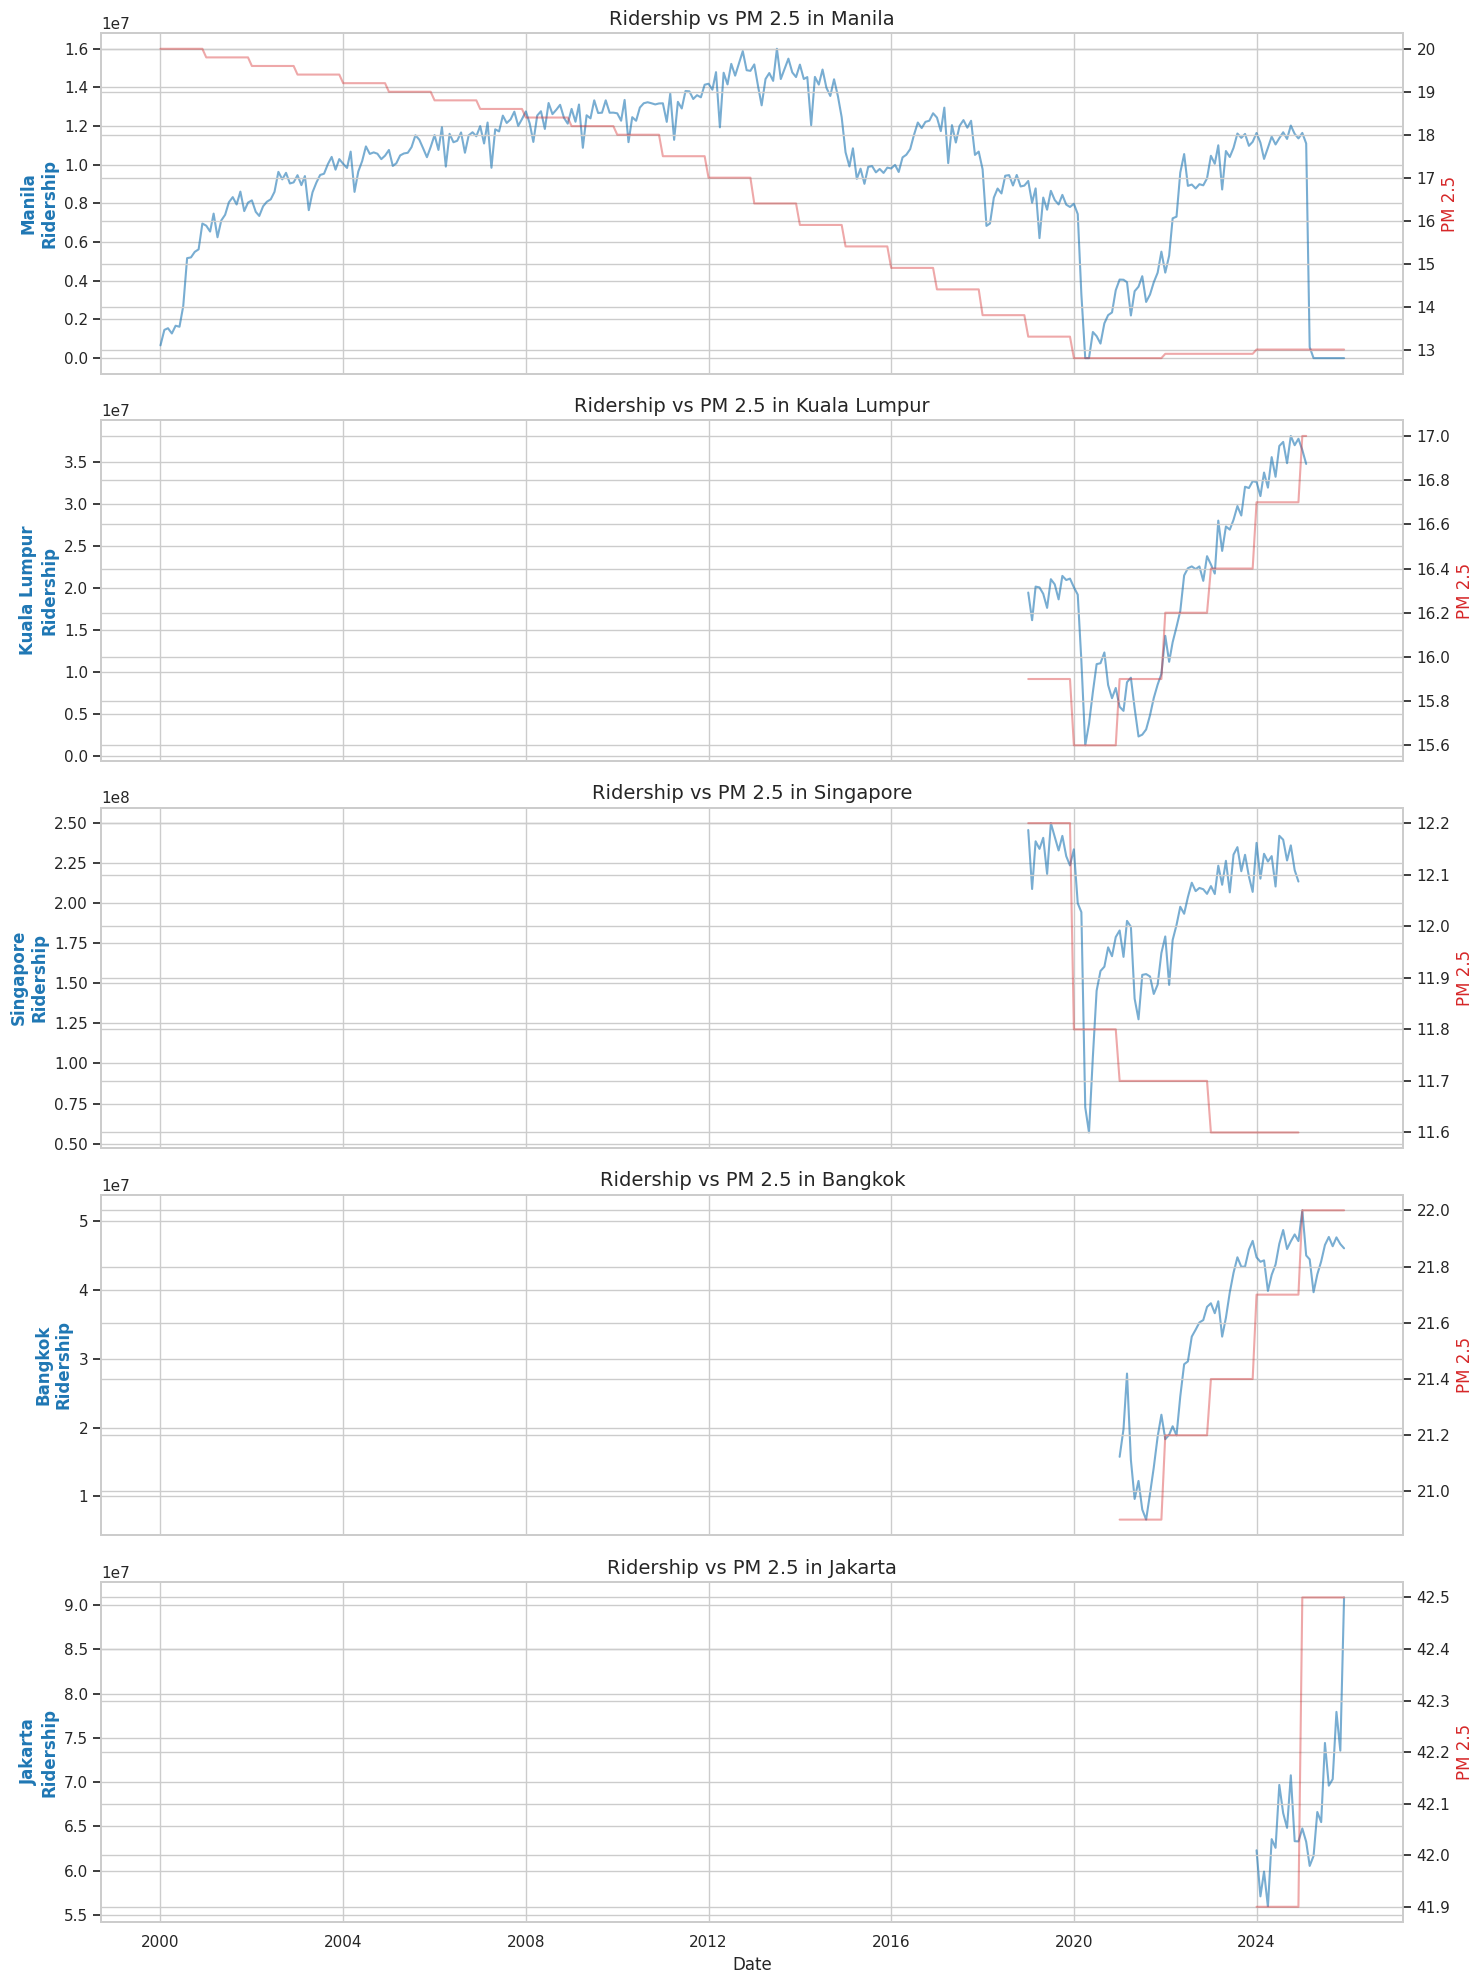

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. เตรียมข้อมูล ---
df = pd.read_csv("ASEAN_Urban_Growth_Final_with_Mode.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# รวม Ridership ทุก Mode ของแต่ละเมืองในแต่ละวัน (เพื่อให้เทียบกับค่าฝุ่นรายวันได้)
daily_city_data = df.groupby(['Date', 'City', 'Country']).agg({
    'Ridership': 'sum',
    'PM25_Mean_ug_m3': 'mean'
}).reset_index()

# --- 2. Visualization 1: Dual Axis Time Series (Multi-City) ---
# เราจะสร้าง Subplots ตามจำนวนเมืองที่มี
cities = daily_city_data['City'].unique()
fig, axes = plt.subplots(len(cities), 1, figsize=(15, 4 * len(cities)), sharex=True)

for i, city in enumerate(cities):
    city_df = daily_city_data[daily_city_data['City'] == city].sort_values('Date')

    # แกนซ้าย: Ridership (สีน้ำเงิน)
    ax1 = axes[i]
    sns.lineplot(data=city_df, x='Date', y='Ridership', ax=ax1, color='#1f77b4', alpha=0.6)
    ax1.set_ylabel(f'{city}\nRidership', color='#1f77b4', fontweight='bold')

    # แกนขวา: PM 2.5 (สีแดง)
    ax2 = ax1.twinx()
    sns.lineplot(data=city_df, x='Date', y='PM25_Mean_ug_m3', ax=ax2, color='#d62728', alpha=0.4)
    ax2.set_ylabel('PM 2.5', color='#d62728')

    ax1.set_title(f'Ridership vs PM 2.5 in {city}', fontsize=14)

plt.tight_layout()
plt.show()

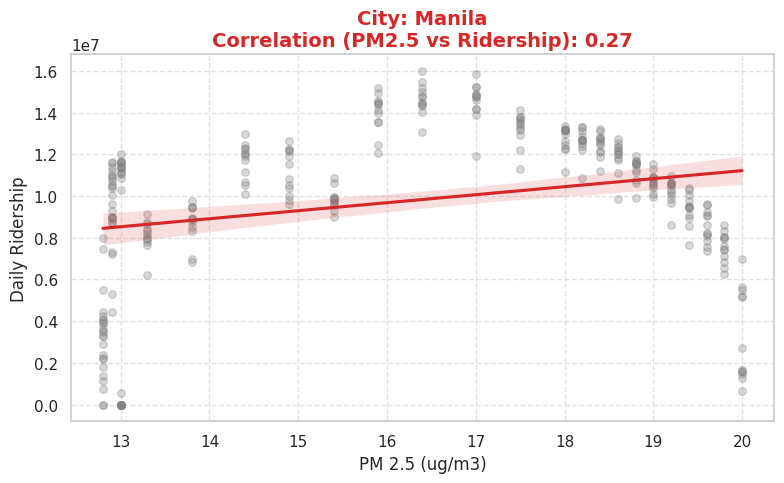

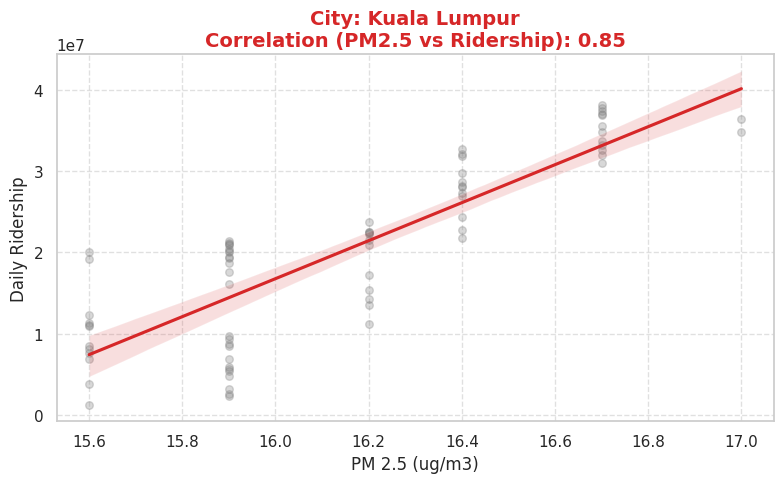

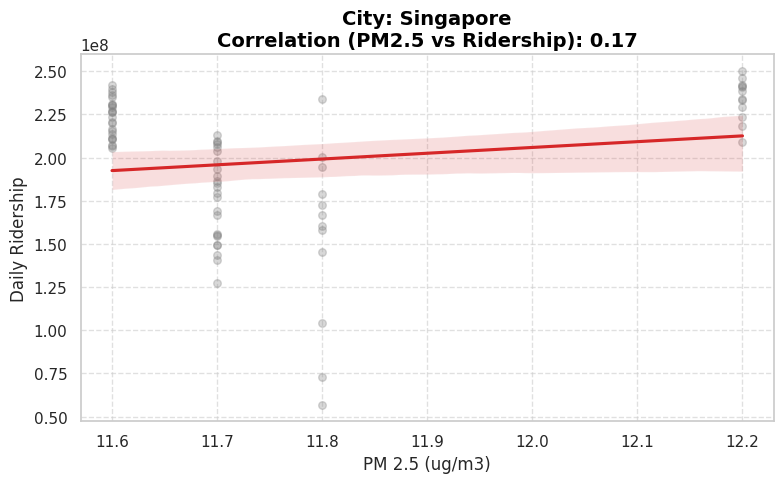

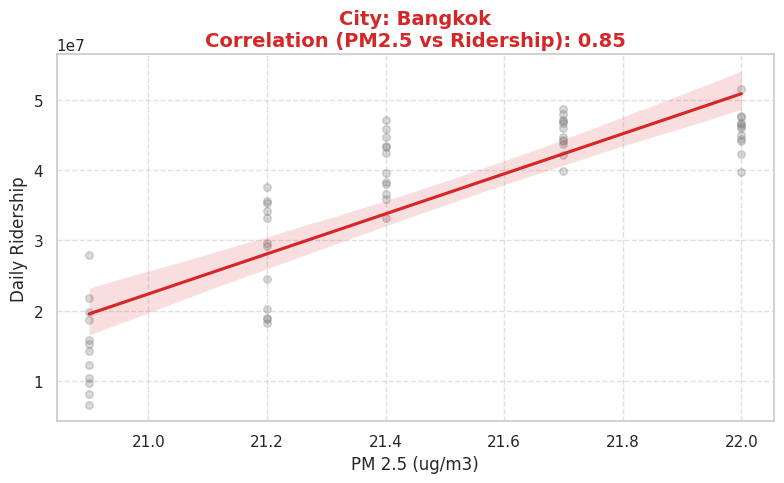

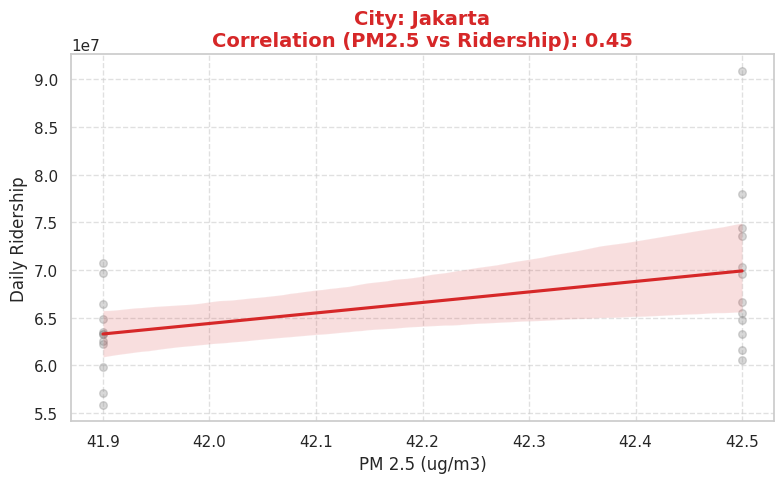

In [6]:
# Get unique cities to ensure we loop through them correctly
unique_cities = daily_city_data['City'].unique()

for city in unique_cities:
    # 1. Filter data for the specific city
    city_df = daily_city_data[daily_city_data['City'] == city]

    # 2. Calculate Correlation
    corr_val = city_df['PM25_Mean_ug_m3'].corr(city_df['Ridership'])

    # 3. Create the figure
    plt.figure(figsize=(8, 5))

    # 4. Draw the regression plot
    sns.regplot(
        data=city_df,
        x="PM25_Mean_ug_m3",
        y="Ridership",
        scatter_kws={'alpha': 0.3, 's': 30, 'color': 'gray'},
        line_kws={'color': '#d62728'}
    )

    # 5. Dynamic Title based on correlation strength
    title_color = '#d62728' if abs(corr_val) > 0.2 else 'black'
    plt.title(f"City: {city}\nCorrelation (PM2.5 vs Ridership): {corr_val:.2f}",
              fontweight='bold', color=title_color, fontsize=14)

    plt.xlabel("PM 2.5 (ug/m3)")
    plt.ylabel("Daily Ridership")

    # Optional: Add a grid for better readability
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()